In [25]:
import pandas as pd
import numpy as np
import plotly.express as px
from matplotlib import pyplot as plt 
import seaborn as sns
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = None
pd.options.display.max_columns = None
sns.set();

In [26]:
df = pd.read_csv("test.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Employee ID               14900 non-null  int64
 1   Age                       14900 non-null  int64
 2   Gender                    14900 non-null  str  
 3   Years at Company          14900 non-null  int64
 4   Job Role                  14900 non-null  str  
 5   Monthly Income            14900 non-null  int64
 6   Work-Life Balance         14900 non-null  str  
 7   Job Satisfaction          14900 non-null  str  
 8   Performance Rating        14900 non-null  str  
 9   Number of Promotions      14900 non-null  int64
 10  Overtime                  14900 non-null  str  
 11  Distance from Home        14900 non-null  int64
 12  Education Level           14900 non-null  str  
 13  Marital Status            14900 non-null  str  
 14  Number of Dependents      14900 non-null  int64
 

# Bivariate analysis

In [27]:
df.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,"14,900.00","14,900.00","14,900.00","14,900.00","14,900.00","14,900.00","14,900.00","14,900.00"
mean,"37,339.02",38.39,15.59,"7,287.31",0.83,49.93,1.66,55.60
std,"21,453.13",12.10,11.13,"2,156.74",1.00,28.70,1.55,25.35
min,5.00,18.00,1.00,"1,226.00",0.00,1.00,0.00,2.00
25%,"18,825.50",28.00,7.00,"5,633.75",0.00,25.00,0.00,36.00
50%,"37,433.00",38.00,13.00,"7,332.00",1.00,50.00,1.00,56.00
75%,"55,857.50",49.00,23.00,"8,852.00",2.00,75.00,3.00,75.00
max,"74,471.00",59.00,51.00,"15,063.00",4.00,99.00,6.00,127.00


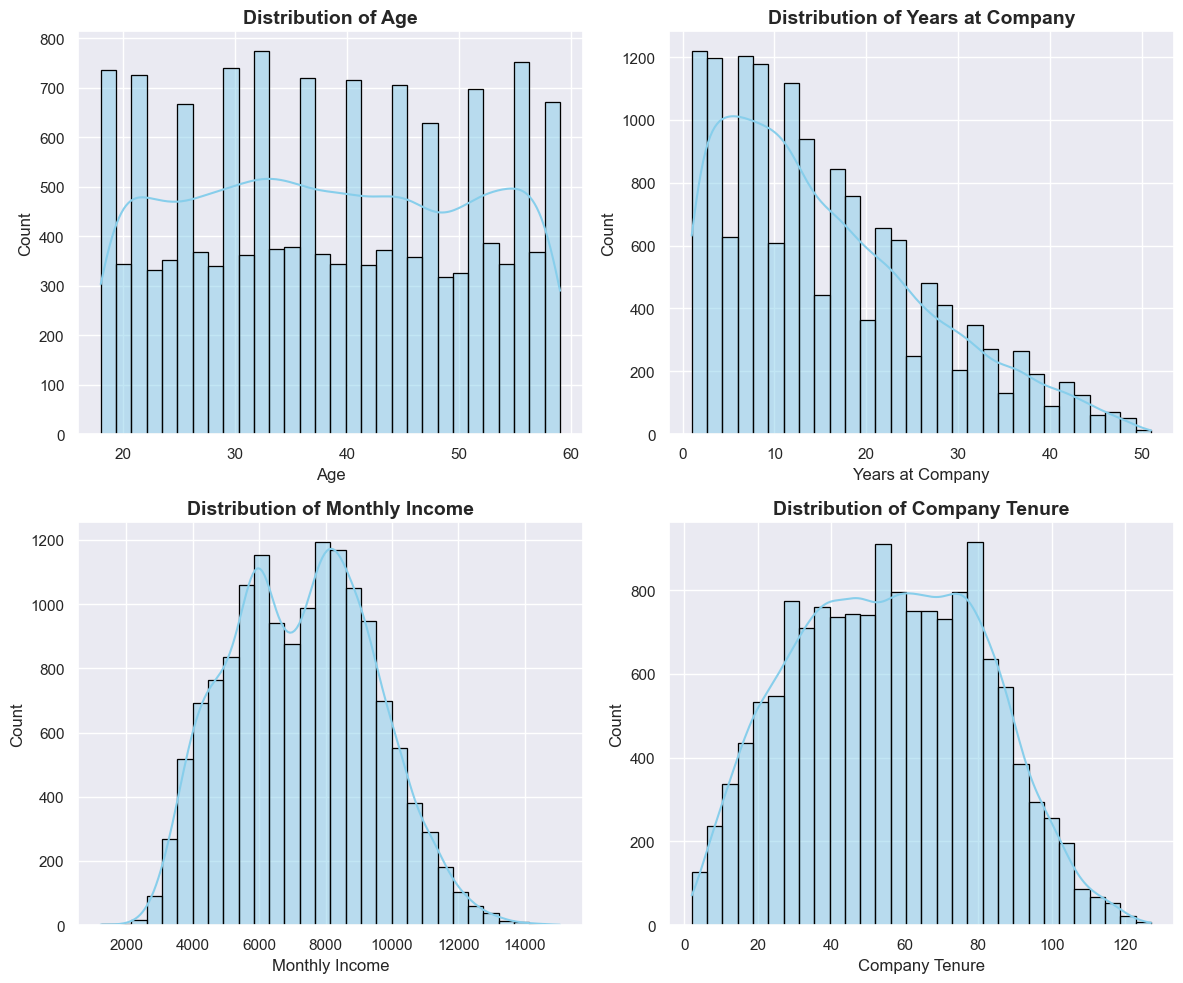

In [28]:
columns = ['Age', 'Years at Company', 'Monthly Income', 'Company Tenure']
plt.figure(figsize=(12,10))
for e, col in enumerate(columns):
    plt.subplot(2,2, e+1)
    sns.histplot(data=df, x=col, kde=True, bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

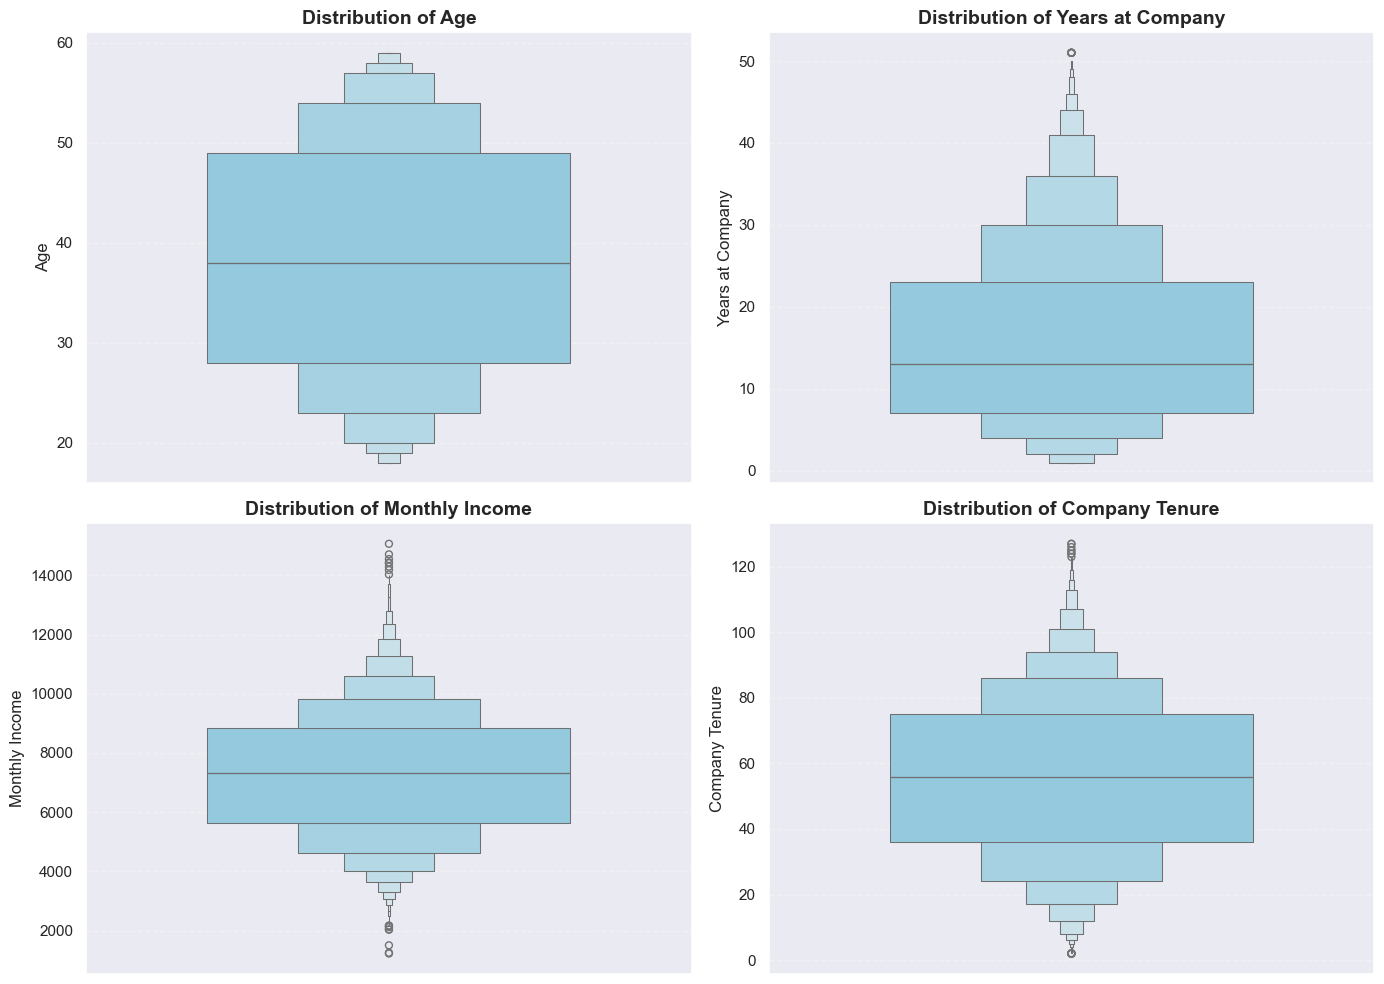

In [29]:
columns = ['Age', 'Years at Company', 'Monthly Income', 'Company Tenure']
plt.figure(figsize=(14, 10))

for e, col in enumerate(columns):
    plt.subplot(2, 2, e+1)
    sns.boxenplot(data=df, y=col, color='skyblue', width=0.6)
    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    plt.ylabel(col, fontsize=12)
    plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Employee ID               14900 non-null  int64
 1   Age                       14900 non-null  int64
 2   Gender                    14900 non-null  str  
 3   Years at Company          14900 non-null  int64
 4   Job Role                  14900 non-null  str  
 5   Monthly Income            14900 non-null  int64
 6   Work-Life Balance         14900 non-null  str  
 7   Job Satisfaction          14900 non-null  str  
 8   Performance Rating        14900 non-null  str  
 9   Number of Promotions      14900 non-null  int64
 10  Overtime                  14900 non-null  str  
 11  Distance from Home        14900 non-null  int64
 12  Education Level           14900 non-null  str  
 13  Marital Status            14900 non-null  str  
 14  Number of Dependents      14900 non-null  int64
 

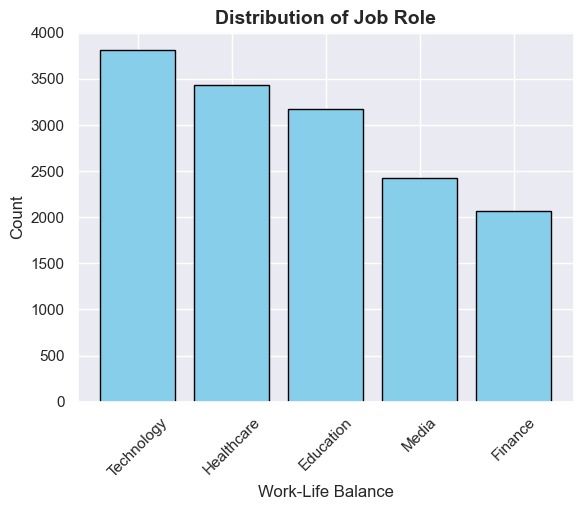

In [35]:
value_count = df['Job Role'].value_counts()
plt.bar(value_count.index, value_count.values, color='skyblue', edgecolor='black')
plt.title(f'Distribution of Job Role', fontsize=14, fontweight='bold')
plt.xlabel(col, fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tick_params(axis='x', rotation=45)

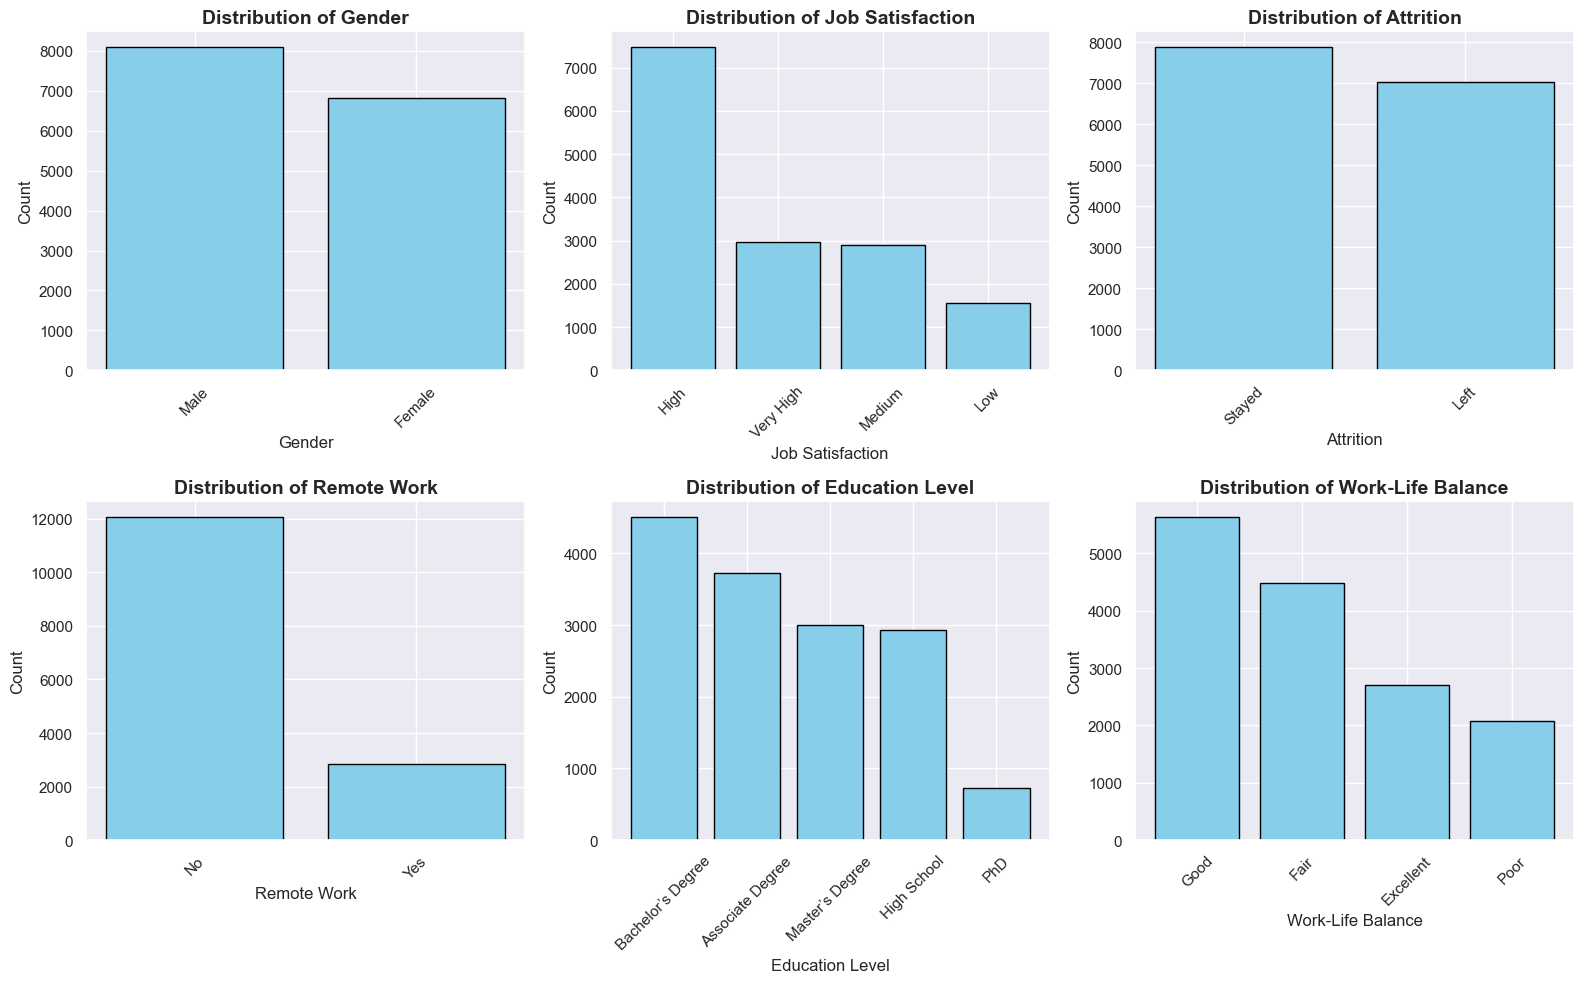

In [36]:
categorical_cols = ['Gender', 'Job Satisfaction', 'Attrition', 'Remote Work', 'Education Level', 'Work-Life Balance']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    axes[idx].bar(value_counts.index, value_counts.values, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=12)
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# bivariate analysis

## why people leave work

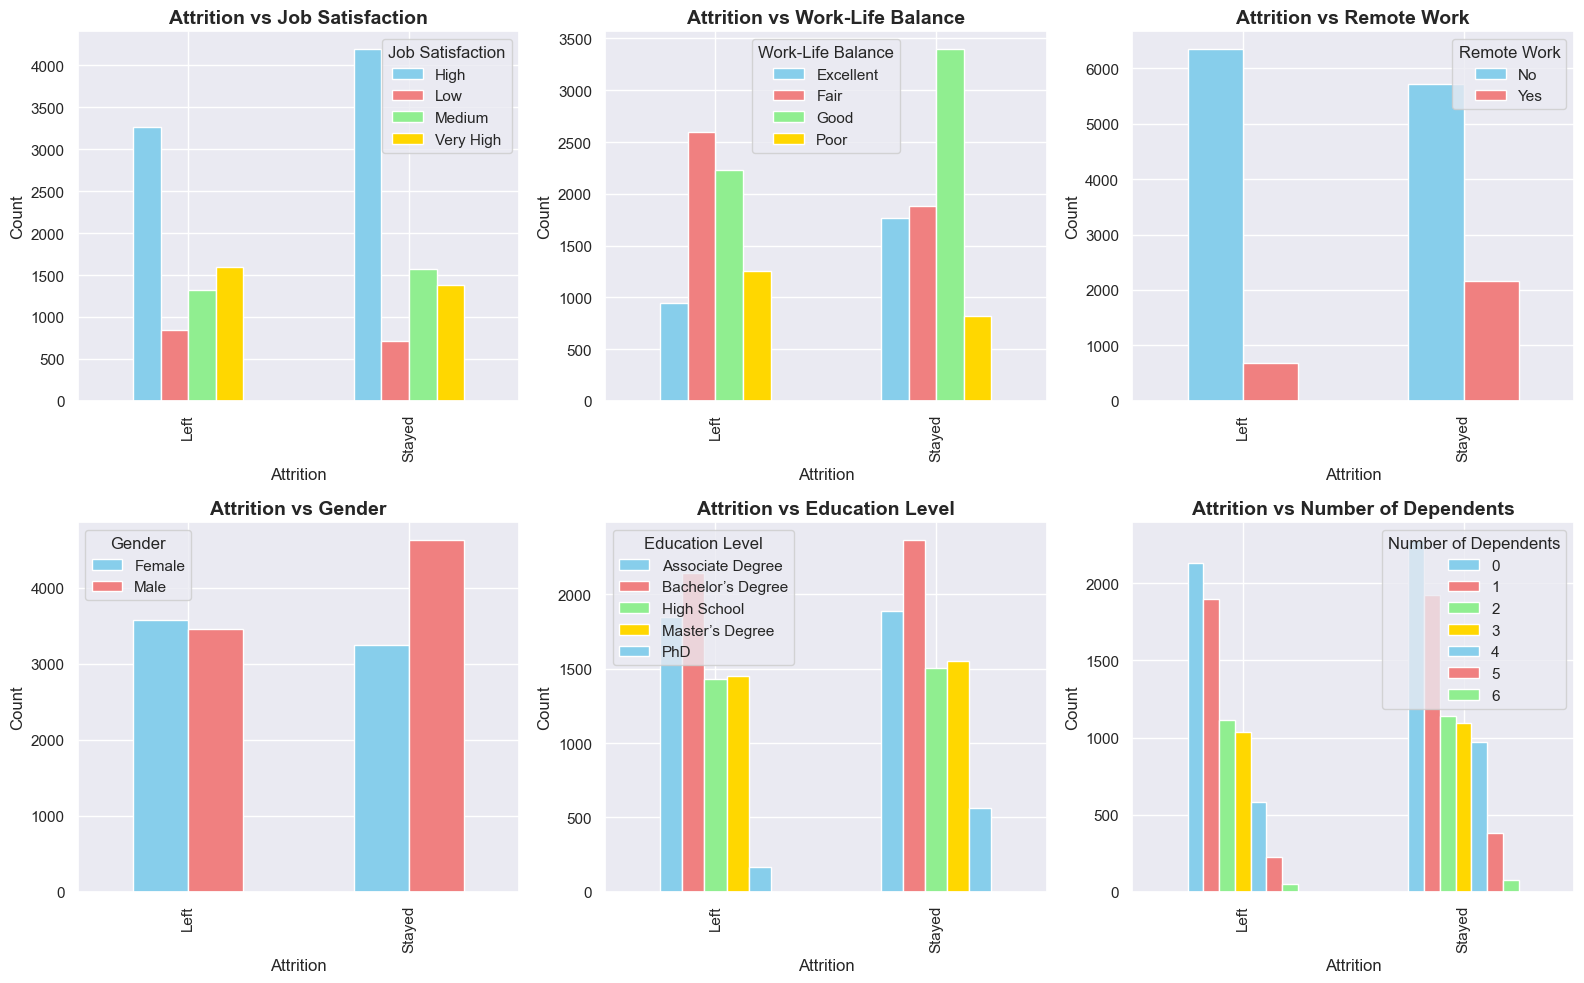

In [48]:
cols = ['Job Satisfaction', 'Work-Life Balance', 'Remote Work', 'Gender', 'Education Level', 'Number of Dependents']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(cols):
    crosstab = pd.crosstab(df['Attrition'], df[col])
    crosstab.plot(kind='bar', ax=axes[idx], color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
    axes[idx].set_title(f'Attrition vs {col}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Attrition', fontsize=12)
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].legend(title=col)

plt.tight_layout()
plt.show()


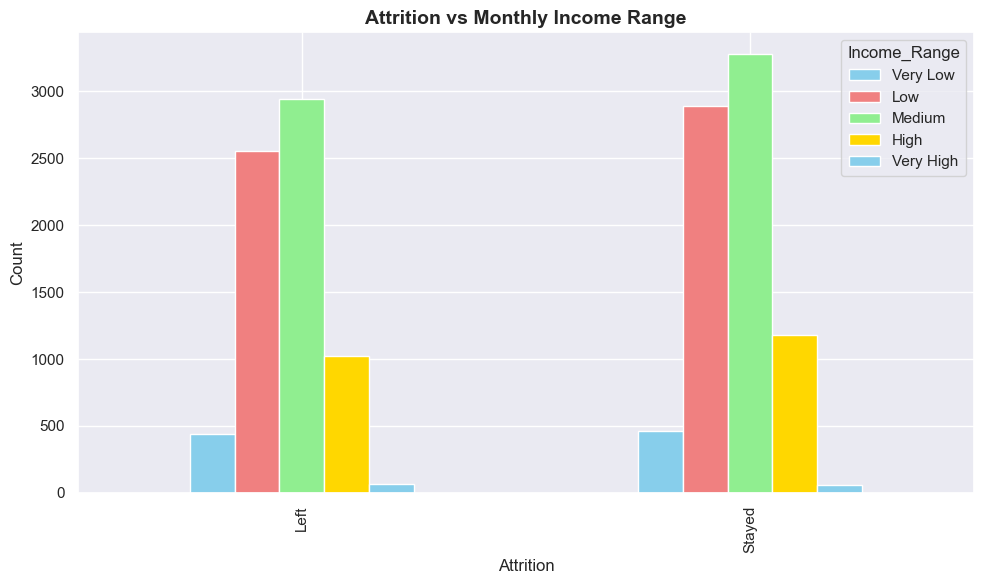

In [51]:
df['Income_Range'] = pd.cut(df['Monthly Income'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

crosstab = pd.crosstab(df['Attrition'], df['Income_Range'])
crosstab.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Attrition vs Monthly Income Range', fontsize=14, fontweight='bold')
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

#### Employees are more likely to stay when they have good work-life balance and remote work options. Employees with fair or poor work-life balance tend to leave the company. Job satisfaction alone does not prevent attrition - other factors like work environment and flexibility matter more.